# Spatial resolution reasoning 

Creating some figures to help decide and reason why I should use a particular spatial resolution. 

TODO: 
2. ? Autocorrelation figure 


In [2]:
import numpy as np 
import pandas as pd 
import xarray as xr
import rioxarray as rxa

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

from pyinterpolate import reproject_flat, build_experimental_variogram

Load one coherence scene. I want to use geolocated, fine resolution data to explore how coherence is correlated spatially in m. 

I am using [this documentation](https://pyinterpolate.readthedocs.io/en/latest/usage/tutorials/functional/1-1-semivariogram-exploration.html) for `pyinterpolate`

First reprojecting to 8826, what I think is the appropriate UTM zone for Idaho. 

In [3]:
# load data
data_dir = '../data/'

# i'll need to reproject the data to a flat coord system. maybe i should change this permanently... 
data_file = data_dir + 'lowman_05208_coherence_20200131_20200213.tif'

# read in tif and reproject
ds = rxa.open_rasterio(data_file, masked=True).squeeze()
ds_reprojected = ds.rio.reproject('EPSG:8826')

Sanity check for reprojection! 

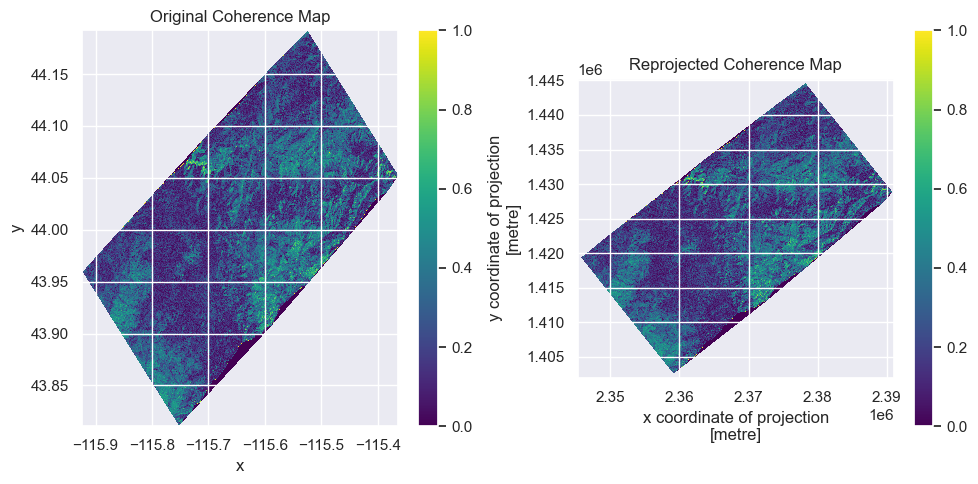

In [4]:
# plot the old vs the new coherence map 
plt.figure(figsize=(10, 5))

# ax[0].imshow(ds, cmap='viridis')
# ax[0].set_title("Original Coherence Map")
# ax[1].imshow(ds_reprojected, cmap='viridis')
# ax[1].set_title("Reprojected Coherence Map")
# # make subplots equal size

# plt.tight_layout()
# plt.show()
plt.subplot(1, 2, 1)
ds.plot.imshow()
plt.title("Original Coherence Map")
ax = plt.subplot(1, 2, 2)
ds_reprojected.plot.imshow(ax=ax)
ax.set_aspect('equal')
plt.title("Reprojected Coherence Map")
plt.tight_layout()
plt.show()

In [5]:
dem_dir = '../data/'
dem = rxa.open_rasterio(dem_dir + 'SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif')
dem_reprojected = dem.rio.reproject('EPSG:8826', resolution=(20,20)) # try estimate_utm from rxa - ask nani 

In [6]:
# clip coherences to the MCS extent and resolution
ds_reprojected_clip = ds_reprojected.rio.reproject_match(dem_reprojected)
ds_reprojected_clip

<xarray.DataArray (y: 435, x: 409)> Size: 712kB
array([[0.24255665, 0.33227292, 0.3450347 , ..., 0.2930393 , 0.37359908,
        0.38382548],
       [0.26134244, 0.26983988, 0.29370642, ..., 0.3863014 , 0.3801429 ,
        0.4338984 ],
       [0.45958304, 0.3104584 , 0.34225088, ..., 0.38785872, 0.34924015,
        0.32216358],
       ...,
       [0.20958255, 0.21977854, 0.2411107 , ..., 0.2496771 , 0.26276395,
        0.25177804],
       [0.07818834, 0.08955722, 0.10812353, ..., 0.23130053, 0.22819568,
        0.22652005],
       [0.13661604, 0.22521928, 0.24858487, ..., 0.2731616 , 0.23712963,
        0.23926261]], shape=(435, 409), dtype=float32)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 3kB 2.361e+06 2.361e+06 ... 2.369e+06 2.369e+06
  * y            (y) float64 3kB 1.422e+06 1.422e+06 ... 1.413e+06 1.413e+06
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [28]:
# turn rioxarray into [x, y, value] for variogram
xs, ys = np.meshgrid(ds_reprojected_clip["x"].values, ds_reprojected_clip["y"].values)
vals = ds_reprojected_clip.values  # shape (ny, nx)
print(vals.shape)
arr = np.column_stack([xs.ravel(), ys.ravel(), vals.ravel()])
arr = arr[~np.isnan(arr[:, 2])]
arr.shape

(435, 409)


(177915, 3)

step_size 5 / max_range 500 is much too big. 
`Unable to allocate 3.24 PiB for an array with shape (21341476, 21341476) and data type float64` <br> 

Try again with step_size 10 / max_range 100

The problem is that the coherence matrix is too big. I will zoom in on MCS? 


In [29]:
# generate 100 random points for variogram calculation
np.random.seed(42)
random_indices = np.random.choice(arr.shape[0], size=10000, replace=False)
sampled_arr = arr[random_indices]

In [19]:
vario = build_experimental_variogram(values = sampled_arr[:, -1], 
                                     geometries = sampled_arr[:, :-1], 
                                     step_size = 5, # bins for the variogram 
                                     max_range = 500) # maximum distance to consider 

# vario.plot(covariance=False)

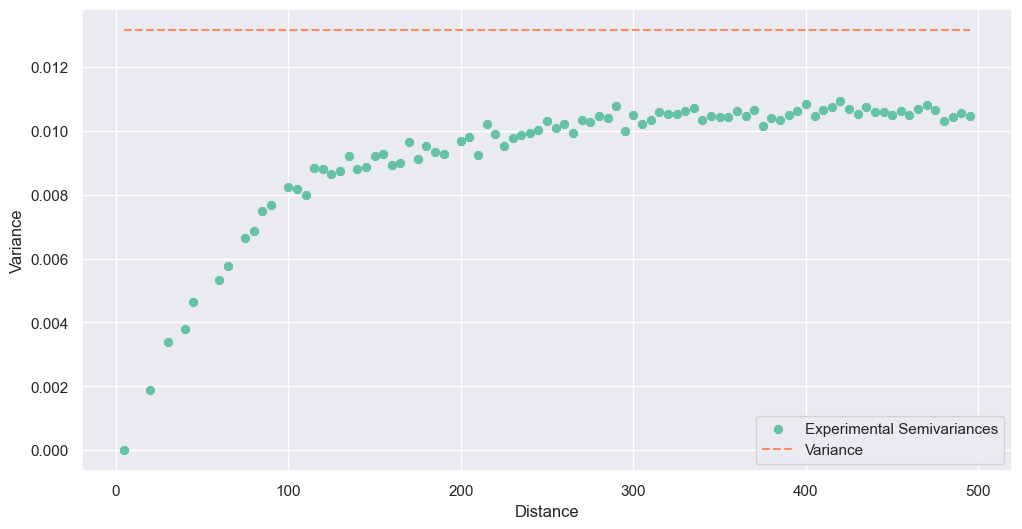

In [20]:
vario.plot(covariance=False)

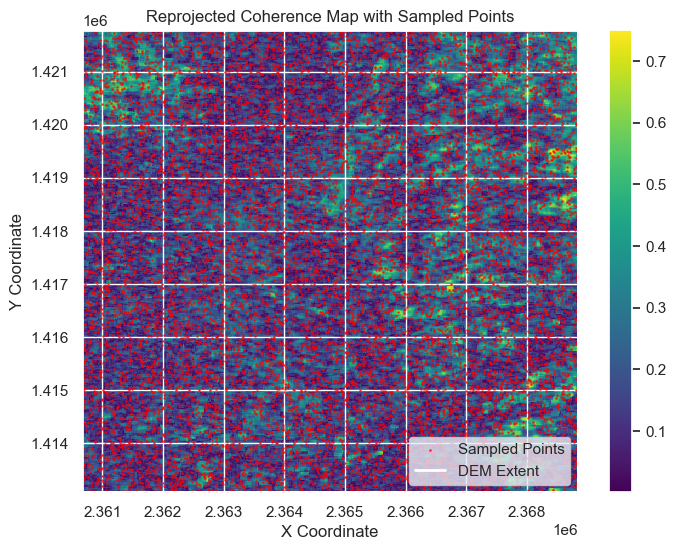

In [32]:
# plot the coherence map with the sampled points overlaid
plt.figure(figsize=(8, 6))
ds_reprojected_clip.plot.imshow(cmap='viridis')
plt.scatter(sampled_arr[:, 0], sampled_arr[:, 1], c='red',
            s=1, label='Sampled Points', alpha=0.6)
# add outline of dem extent
dem_reprojected.rio.bounds()
bounds = dem_reprojected.rio.bounds()
plt.plot([bounds[0], bounds[2], bounds[2], bounds[0], bounds[0]],
         [bounds[1], bounds[1], bounds[3], bounds[3], bounds[1]],
         color='white', linewidth=2, label='DEM Extent')
plt.title("Reprojected Coherence Map with Sampled Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

This is for just the Mores Creek LiDAR survey site. Where semivariance is lower, points are more similar. As we get further apart, dissimilarity increases. At distances of about 150 m away, semivariance stops increasing, so points about 150m away from each other are about as dissimilar as points 400 m apart. 

We might interpret this to mean that points that are within 150 m of each other are similar enough that we can consider them all to be part of one pixel. 

In [24]:
# try variogram with 10m resolution data
ds_reprojected10m = ds.rio.reproject('EPSG:8826', resolution=(10,10))

xs, ys = np.meshgrid(ds_reprojected10m["x"].values, ds_reprojected10m["y"].values)
vals = ds_reprojected10m.values  # shape (ny, nx)
arr = np.column_stack([xs.ravel(), ys.ravel(), vals.ravel()])
arr = arr[~np.isnan(arr[:, 2])]

print(arr.shape)

np.random.seed(35)
random_indices = np.random.choice(arr.shape[0], size=20000, replace=False)
sampled_arr = arr[random_indices]

vario = build_experimental_variogram(values = sampled_arr[:, -1], 
                                     geometries = sampled_arr[:, :-1], 
                                     step_size = 10, # bins for the variogram 
                                     max_range = 1000) # maximum distance to consider 

(8714978, 3)


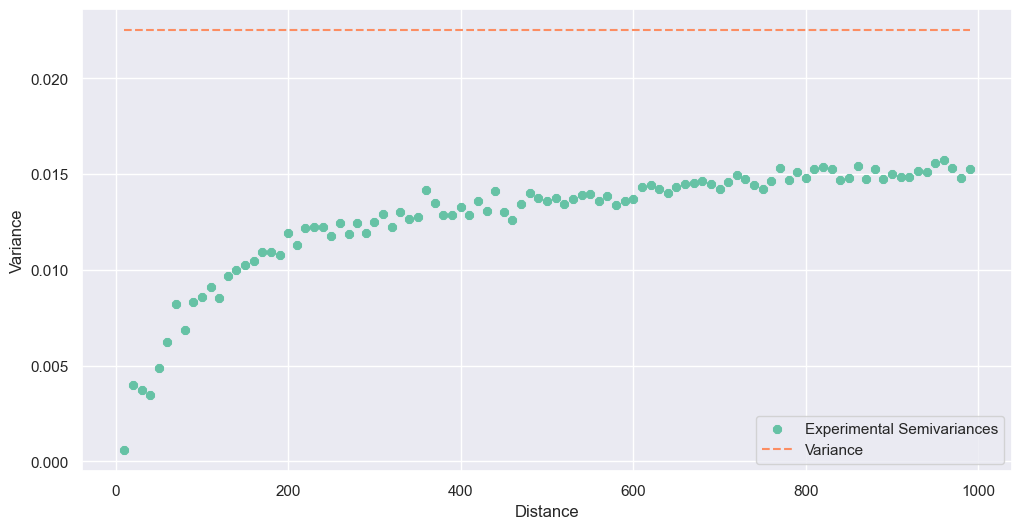

In [25]:
# plot
vario.plot(covariance=False)

This is for the full image with 10m resolution. The semivariance crosses overall dataset variance around 400 m. 

It took ~15 sec to produce with 10k points and ~90 sec with 20k points. 
Memory seems to be the issue for this problem - I could try running these on the super computer for more info, but I'm not sure I need to...

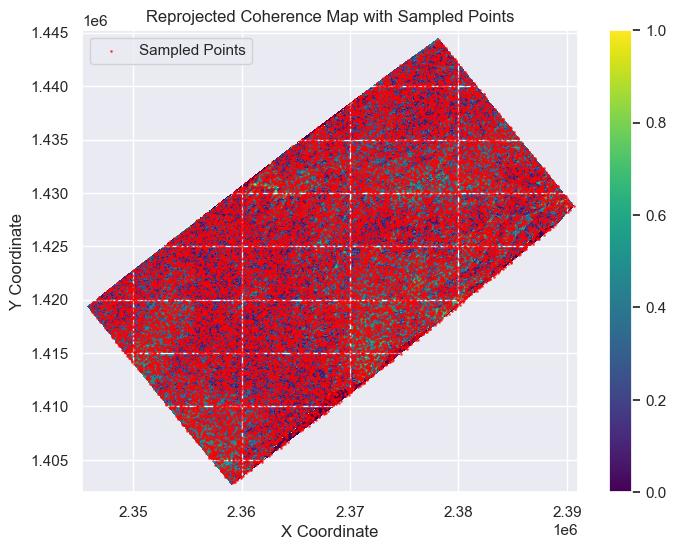

In [27]:
# plot the coherence map with the sampled points overlaid
plt.figure(figsize=(8, 6))
ds_reprojected10m.plot.imshow(cmap='viridis')
plt.scatter(sampled_arr[:, 0], sampled_arr[:, 1], c='red',
            s=1, label='Sampled Points', alpha=0.6)
plt.title("Reprojected Coherence Map with Sampled Points")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

TODO: 
- Look at another region? Grand Mesa for its substantially different environment? 